# Financial Market Analysis

## Project Objective

This project analyses the historical performance of multiple stocks using Python.

The objective is to compare investment returns, volatility and correlations between stocks, and use the results to evaluate their risk and performance characteristics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
stocks = pd.DataFrame({
    "Date": pd.date_range(start="2025-01-01", periods=15),

    "Alpha": [
        100, 102, 101, 105, 108,
        107, 111, 114, 113, 117,
        120, 118, 122, 125, 128
    ],

    "Beta": [
        80, 81, 83, 82, 84,
        86, 85, 88, 90, 89,
        91, 93, 92, 95, 97
    ],

    "Gamma": [
        150, 148, 151, 149, 153,
        156, 154, 158, 161, 159,
        163, 166, 164, 168, 171
    ],

    "Delta": [
        60, 62, 61, 64, 63,
        66, 68, 67, 70, 72,
        71, 74, 76, 75, 79
    ]
})

In [3]:
stocks.head()

,Date,Alpha,Beta,Gamma,Delta
0,2025-01-01,100,80,150,60
1,2025-01-02,102,81,148,62
2,2025-01-03,101,83,151,61
3,2025-01-04,105,82,149,64
4,2025-01-05,108,84,153,63


In [4]:
stocks.dtypes

Date     datetime64[us]
Alpha             int64
Beta              int64
Gamma             int64
Delta             int64
dtype: object

In [5]:
stocks.isnull().sum()

Date     0
Alpha    0
Beta     0
Gamma    0
Delta    0
dtype: int64

In [6]:
stocks.shape

(15, 5)

### Initial Data Inspection

The dataset contains 15 observations across four stocks. The Date column is correctly stored as a datetime, the stock price columns are numeric, and there are no missing values in the dataset.

In [7]:
stocks["Alpha_Return"] = stocks["Alpha"].pct_change() * 100
stocks["Beta_Return"] = stocks["Beta"].pct_change() * 100
stocks["Gamma_Return"] = stocks["Gamma"].pct_change() * 100
stocks["Delta_Return"] = stocks["Delta"].pct_change() * 100

In [8]:
stocks[
    ["Date", "Alpha_Return", "Beta_Return",
     "Gamma_Return", "Delta_Return"]
].head()

,Date,Alpha_Return,Beta_Return,Gamma_Return,Delta_Return
0,2025-01-01,NaN,NaN,NaN,NaN
1,2025-01-02,2.000000,1.250000,-1.333333,3.333333
2,2025-01-03,-0.980392,2.469136,2.027027,-1.612903
3,2025-01-04,3.960396,-1.204819,-1.324503,4.918033
4,2025-01-05,2.857143,2.439024,2.684564,-1.562500


## Daily Returns Analysis

Daily percentage returns were calculated to measure the day-to-day change in each stock's price.

In [9]:
stocks["Alpha_Return"].mean()

np.float64(1.7972252928154764)

In [10]:
stocks["Beta_Return"].mean()

np.float64(1.3998848314393282)

In [11]:
stocks["Gamma_Return"].mean()

np.float64(0.9544658135077108)

In [12]:
stocks["Delta_Return"].mean()

np.float64(2.02064621677901)

### Daily Return Insight

Delta had the highest average daily return at approximately 2.02%, followed by Alpha at 1.80%. However, average return alone does not determine which stock performed best because the level of volatility and risk must also be considered.

## Volatility and Risk Analysis

Volatility measures how much a stock's daily returns fluctuate. A higher standard deviation indicates greater volatility and therefore greater risk.

In [13]:
stocks["Alpha_Return"].std()

np.float64(1.993755547949107)

In [14]:
stocks["Beta_Return"].std()

np.float64(1.7454006541391267)

In [15]:
stocks["Gamma_Return"].std()

np.float64(1.749338022122981)

In [16]:
stocks["Delta_Return"].std()

np.float64(2.8103545228814135)

### Volatility Insight

Delta had the highest volatility, meaning its daily returns fluctuated the most and it carried the highest level of risk. Gamma had the lowest volatility, indicating more stable daily returns.

In [17]:
volatility = stocks[
    ["Alpha_Return", "Beta_Return", "Gamma_Return", "Delta_Return"]
].std()

volatility

Alpha_Return    1.993756
Beta_Return     1.745401
Gamma_Return    1.749338
Delta_Return    2.810355
dtype: float64

### Volatility Insight

Delta had the highest volatility at approximately 2.81%, meaning its daily returns fluctuated the most. Beta and Gamma had the lowest volatility at approximately 1.75%, indicating more stable daily returns.

## Total Return Analysis

Total return measures the percentage change in each stock's price from the beginning to the end of the analysis period.

In [18]:
alpha_total = (
    (stocks["Alpha"].iloc[-1] - stocks["Alpha"].iloc[0])
    / stocks["Alpha"].iloc[0]
) * 100

beta_total = (
    (stocks["Beta"].iloc[-1] - stocks["Beta"].iloc[0])
    / stocks["Beta"].iloc[0]
) * 100

gamma_total = (
    (stocks["Gamma"].iloc[-1] - stocks["Gamma"].iloc[0])
    / stocks["Gamma"].iloc[0]
) * 100

delta_total = (
    (stocks["Delta"].iloc[-1] - stocks["Delta"].iloc[0])
    / stocks["Delta"].iloc[0]
) * 100

In [19]:
print("Alpha:", round(alpha_total, 2), "%")
print("Beta:", round(beta_total, 2), "%")
print("Gamma:", round(gamma_total, 2), "%")
print("Delta:", round(delta_total, 2), "%")

Alpha: 28.0 %
Beta: 21.25 %
Gamma: 14.0 %
Delta: 31.67 %


### Total Return Insight

Delta generated the highest total return at approximately 31.67%, followed by Alpha at 28%. Gamma generated the lowest total return at 14%.

## Cumulative Return Analysis

Cumulative return shows how much each stock has gained or lost relative to its starting price over the analysis period.

In [20]:
stocks["Alpha_Cumulative"] = (
    (stocks["Alpha"] - stocks["Alpha"].iloc[0])
    / stocks["Alpha"].iloc[0]
) * 100

stocks["Beta_Cumulative"] = (
    (stocks["Beta"] - stocks["Beta"].iloc[0])
    / stocks["Beta"].iloc[0]
) * 100

stocks["Gamma_Cumulative"] = (
    (stocks["Gamma"] - stocks["Gamma"].iloc[0])
    / stocks["Gamma"].iloc[0]
) * 100

stocks["Delta_Cumulative"] = (
    (stocks["Delta"] - stocks["Delta"].iloc[0])
    / stocks["Delta"].iloc[0]
) * 100

In [21]:
stocks[
    ["Date", "Alpha_Cumulative", "Beta_Cumulative",
     "Gamma_Cumulative", "Delta_Cumulative"]
].tail()

,Date,Alpha_Cumulative,Beta_Cumulative,Gamma_Cumulative,Delta_Cumulative
10,2025-01-11,20.0,13.75,8.666667,18.333333
11,2025-01-12,18.0,16.25,10.666667,23.333333
12,2025-01-13,22.0,15.00,9.333333,26.666667
13,2025-01-14,25.0,18.75,12.000000,25.000000
14,2025-01-15,28.0,21.25,14.000000,31.666667


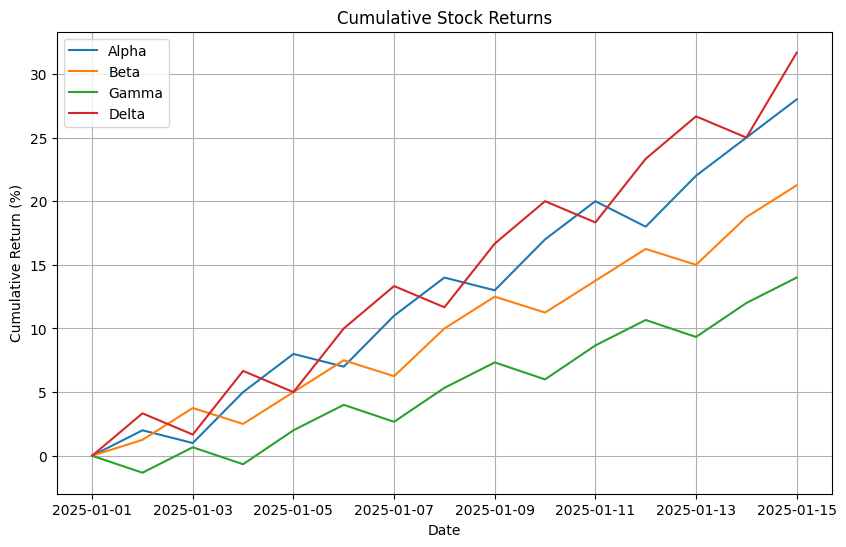

In [22]:
plt.figure(figsize=(10, 6))

plt.plot(stocks["Date"], stocks["Alpha_Cumulative"], label="Alpha")
plt.plot(stocks["Date"], stocks["Beta_Cumulative"], label="Beta")
plt.plot(stocks["Date"], stocks["Gamma_Cumulative"], label="Gamma")
plt.plot(stocks["Date"], stocks["Delta_Cumulative"], label="Delta")

plt.title("Cumulative Stock Returns")
plt.xlabel("Date")
plt.ylabel("Cumulative Return (%)")
plt.legend()
plt.grid(True)

plt.show()

### Cumulative Return Insight

All four stocks produced positive cumulative returns during the period. Delta finished with the strongest cumulative performance, followed by Alpha, while Gamma produced the lowest cumulative return.

## Best and Worst Daily Returns

The maximum and minimum daily returns were calculated to identify the strongest and weakest trading days for each stock.

In [23]:
return_columns = [
    "Alpha_Return",
    "Beta_Return",
    "Gamma_Return",
    "Delta_Return"
]

stocks[return_columns].max()

Alpha_Return    3.960396
Beta_Return     3.529412
Gamma_Return    2.684564
Delta_Return    5.333333
dtype: float64

In [24]:
stocks[return_columns].min()

Alpha_Return   -1.666667
Beta_Return    -1.204819
Gamma_Return   -1.333333
Delta_Return   -1.612903
dtype: float64

### Daily Movement Insight

Delta recorded the largest single-day gain at approximately 5.33%. Alpha experienced the largest single-day decline at approximately -1.67%.

## Correlation Analysis

Correlation measures the relationship between the daily returns of different stocks. Values close to +1 indicate a strong positive relationship, while values close to -1 indicate a strong negative relationship.

In [25]:
correlation = stocks[
    ["Alpha_Return", "Beta_Return", "Gamma_Return", "Delta_Return"]
].corr()

correlation

,Alpha_Return,Beta_Return,Gamma_Return,Delta_Return
Alpha_Return,1.000000,-0.538486,-0.492131,-0.141782
Beta_Return,-0.538486,1.000000,0.919677,-0.459969
Gamma_Return,-0.492131,0.919677,1.000000,-0.492831
Delta_Return,-0.141782,-0.459969,-0.492831,1.000000


### Correlation Insight

Beta and Gamma showed the strongest positive correlation at approximately 0.92, meaning their daily returns tended to move in similar directions during the period.

Several other stock pairs showed negative correlations, suggesting that their daily returns often moved in opposite directions.

## Stock Price Performance

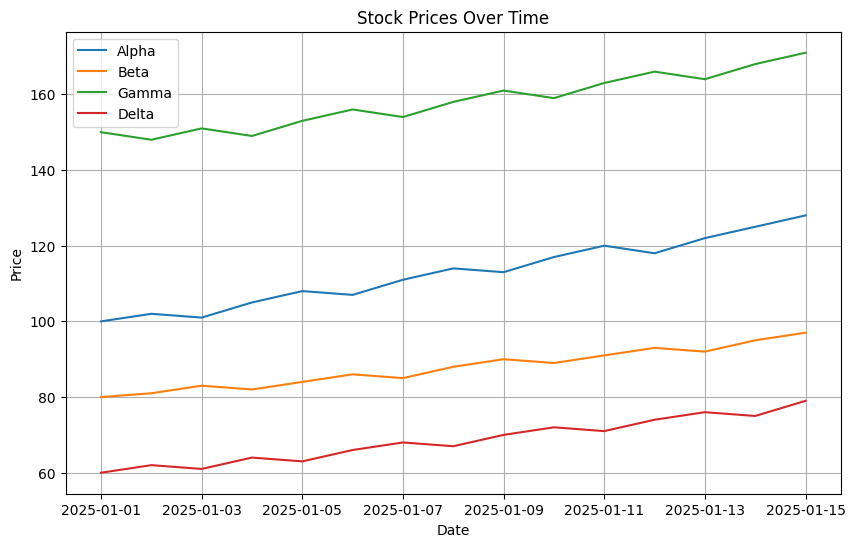

In [26]:
plt.figure(figsize=(10, 6))

plt.plot(stocks["Date"], stocks["Alpha"], label="Alpha")
plt.plot(stocks["Date"], stocks["Beta"], label="Beta")
plt.plot(stocks["Date"], stocks["Gamma"], label="Gamma")
plt.plot(stocks["Date"], stocks["Delta"], label="Delta")

plt.title("Stock Prices Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)

plt.show()

## Risk vs Return Analysis

Average daily return and volatility were compared to evaluate the relationship between risk and performance for each stock.

In [27]:
risk_return = pd.DataFrame({
    "Stock": ["Alpha", "Beta", "Gamma", "Delta"],
    
    "Average_Return": [
        stocks["Alpha_Return"].mean(),
        stocks["Beta_Return"].mean(),
        stocks["Gamma_Return"].mean(),
        stocks["Delta_Return"].mean()
    ],
    
    "Volatility": [
        stocks["Alpha_Return"].std(),
        stocks["Beta_Return"].std(),
        stocks["Gamma_Return"].std(),
        stocks["Delta_Return"].std()
    ]
})

risk_return

,Stock,Average_Return,Volatility
0,Alpha,1.797225,1.993756
1,Beta,1.399885,1.745401
2,Gamma,0.954466,1.749338
3,Delta,2.020646,2.810355


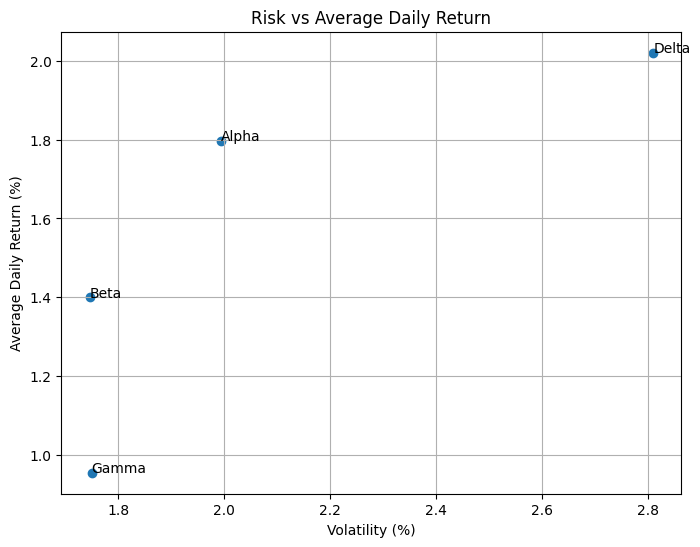

In [28]:
plt.figure(figsize=(8, 6))

plt.scatter(
    risk_return["Volatility"],
    risk_return["Average_Return"]
)

for i in range(len(risk_return)):
    plt.annotate(
        risk_return["Stock"][i],
        (
            risk_return["Volatility"][i],
            risk_return["Average_Return"][i]
        )
    )

plt.title("Risk vs Average Daily Return")
plt.xlabel("Volatility (%)")
plt.ylabel("Average Daily Return (%)")
plt.grid(True)

plt.show()

### Risk vs Return Insight

Delta produced the highest average daily return but also had the highest volatility, demonstrating the trade-off between risk and return.

Alpha produced the second-highest average daily return with substantially lower volatility than Delta.

Gamma had the lowest average daily return and relatively low volatility.

# Key Findings

1. **Delta generated the highest total return**, increasing by approximately 31.67% over the analysis period.

2. **Delta also had the highest average daily return**, at approximately 2.02%.

3. **Delta was the most volatile stock**, with daily return volatility of approximately 2.81%.

4. **Alpha generated the second-highest total return**, at 28%, while experiencing lower volatility than Delta.

5. **Gamma generated the lowest total return**, at approximately 14%.

6. **Beta and Gamma had a strong positive return correlation** of approximately 0.92, indicating that their daily returns frequently moved in similar directions.

7. The analysis demonstrates that **higher returns should be considered alongside risk**, rather than evaluating investment performance using returns alone.

# Conclusion

This project analysed the performance and risk characteristics of four stocks using Python, Pandas, NumPy and Matplotlib.

Daily returns, cumulative returns, total returns, volatility and correlations were used to compare the stocks from both a return and risk perspective.

Delta generated the strongest overall return but also experienced the highest volatility. Alpha produced strong returns with lower volatility than Delta, while Beta and Gamma demonstrated a strong positive correlation in their daily returns.

The analysis highlights the importance of considering both risk and return when comparing financial assets.